# 📊 Interconnect Churn Prediction — Unified Project Notebook

## 🔵 Executive Summary (Non-Technical Audience)

**Business Problem:** Interconnect loses revenue every time a customer cancels (churn). Retaining a customer costs far less than acquiring a new one.

**What we built:** A machine-learning model that predicts — *before it happens* — which customers are likely to cancel, giving the retention team time to act.

**Key results on unseen data:**

| Metric | Value |
|---|---|
| ROC AUC | **0.932** (target: 0.88) ✅ |
| Accuracy | 87% |
| Recall (churn class) | 79% |
| F1-score (churn class) | 0.76 |

**In plain English:** The model correctly flags ~79% of customers who will cancel. For every 100 real churners, ~21 are missed — acceptable for retention campaigns.

**Top drivers of churn:** Tenure (time as customer), total & monthly charges, contract type, and internet service type.

**Recommended actions:**
- Integrate model into CRM → daily/weekly churn-risk alerts
- Target customers with low tenure + high monthly cost with personalised offers
- Retrain model quarterly as market conditions evolve

---


## 📋 Table of Contents
1. [Data Loading & Exploration](#1-data-loading--exploration)
2. [Data Processing & Feature Engineering](#2-data-processing--feature-engineering)
3. [Modelling](#3-modelling)
4. [Final Report](#4-final-report)


---
# 1. Data Loading & Exploration


In [75]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global constants ──────────────────────────────────────────────────────
RANDOM_STATE   = 42
TEST_SIZE      = 0.20
REFERENCE_DATE = pd.Timestamp('2020-02-01')   # last known date in dataset
CV_FOLDS       = 5

print('Libraries loaded successfully.')


Libraries loaded successfully.


### 1.1 List available files


In [76]:
BASE_PATH = '../data/'
print(f'Files in {BASE_PATH}:')
for f in os.listdir(BASE_PATH):
    print(f'  - {f}')


Files in ../data/:
  - personal.csv
  - contract.csv
  - phone.csv
  - internet.csv


### 1.2 Load raw datasets


In [77]:
contracts = pd.read_csv(BASE_PATH + 'contract.csv')
personal  = pd.read_csv(BASE_PATH + 'personal.csv')
internet  = pd.read_csv(BASE_PATH + 'internet.csv')
phone     = pd.read_csv(BASE_PATH + 'phone.csv')

print('Shapes:')
for name, df in [('contracts', contracts), ('personal', personal),
                  ('internet', internet), ('phone', phone)]:
    print(f'  {name:12s}: {df.shape}  |  columns: {list(df.columns)}')


Shapes:
  contracts   : (7043, 8)  |  columns: ['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
  personal    : (7043, 5)  |  columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']
  internet    : (5517, 8)  |  columns: ['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
  phone       : (6361, 2)  |  columns: ['customerID', 'MultipleLines']


### 1.3 Basic data quality — contracts table


In [78]:
contracts.info()
contracts.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15


### 1.4 Temporal distribution of contract start dates


In [79]:
# Temporal conversion — used later for the full churn rate analysis in section 2.3
contracts['BeginDate'] = pd.to_datetime(contracts['BeginDate'])
contracts['month']     = contracts['BeginDate'].dt.to_period('M')
print('BeginDate converted. Full monthly analysis (volume + churn rate) is in section 2.3')
print(f'Date range: {contracts["BeginDate"].min().date()} → {contracts["BeginDate"].max().date()}')
print(f'Total contracts: {len(contracts)}')


BeginDate converted. Full monthly analysis (volume + churn rate) is in section 2.3
Date range: 2013-10-01 → 2020-02-01
Total contracts: 7043


The date range spans from **2013 to early 2020**. The full analysis of new contracts per month and churn rate per cohort is shown together in **section 2.3**, after merging all tables so that `EndDate` (churn signal) is available.


---
# 2. Data Processing & Feature Engineering


### 2.1 Merge all tables (left join on customerID)


In [80]:
df = (
    contracts
    .merge(personal,  on='customerID', how='left')
    .merge(internet,  on='customerID', how='left')
    .merge(phone,     on='customerID', how='left')
)

print(f'Merged shape : {df.shape}')
print(f'Duplicates   : {df.duplicated().sum()}')
df.head(3)


Merged shape : (7043, 21)
Duplicates   : 0


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,month,gender,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,2020-01,Female,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,2017-04,Male,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,2019-10,Male,...,No,No,DSL,Yes,Yes,No,No,No,No,No


### 2.2 Create target variable — churn


Churn distribution:
churn
Active     0.73463
Churned    0.26537


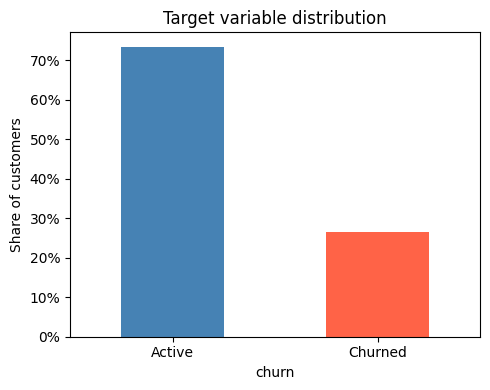

In [81]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'], errors='coerce')
df['EndDate']   = pd.to_datetime(df['EndDate'],   errors='coerce')

# 'No' in EndDate → active (churn=0) | valid date → cancelled (churn=1)
df['churn'] = df['EndDate'].notna().astype(int)

churn_rate = df['churn'].value_counts(normalize=True)
print('Churn distribution:')
print(churn_rate.rename({0: 'Active', 1: 'Churned'}).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
churn_rate.rename({0: 'Active', 1: 'Churned'}).plot.bar(
    ax=ax, color=['steelblue', 'tomato'], rot=0
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Target variable distribution')
ax.set_ylabel('Share of customers')
plt.tight_layout()
plt.show()


### 2.3 Churn rate over time (reviewer suggestion)


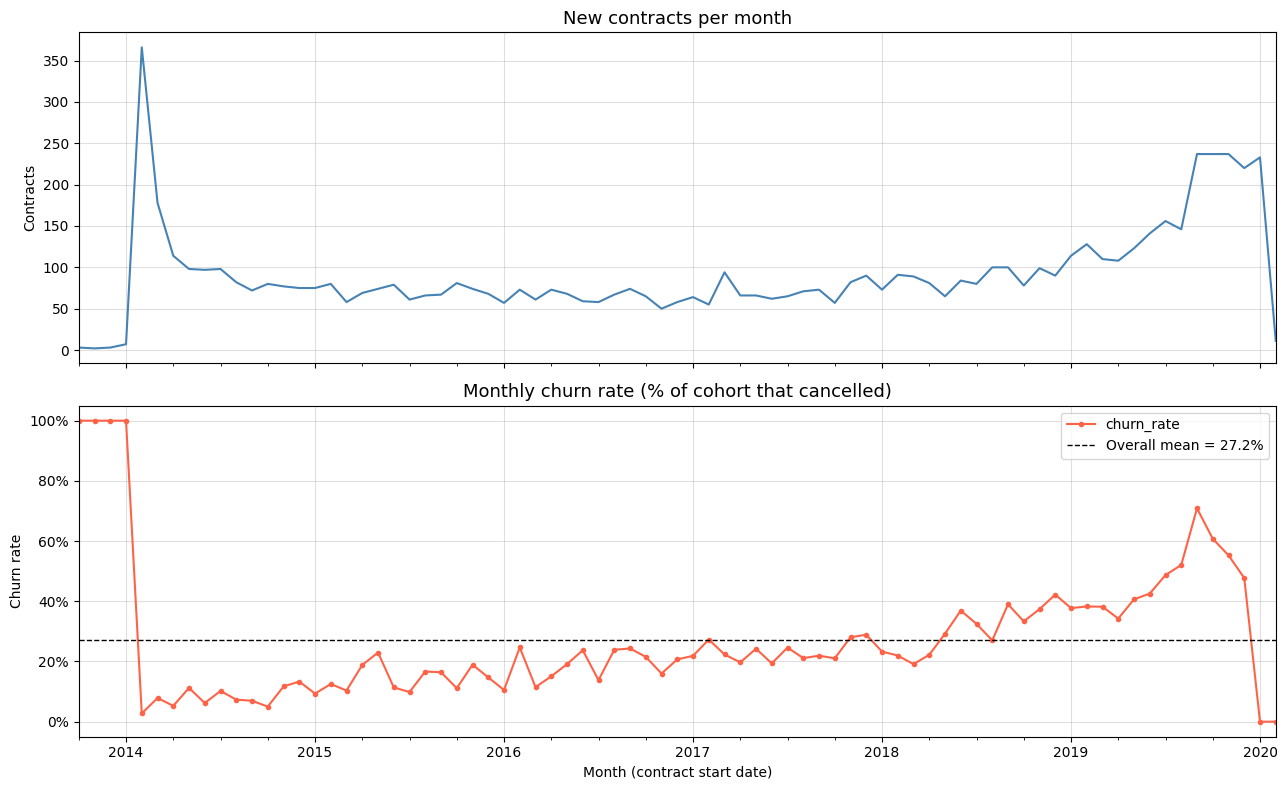

Churn rate statistics by month:
count    7700.0%
mean       27.2%
std        22.2%
min         0.0%
25%        12.5%
50%        21.9%
75%        34.3%
max       100.0%
Name: churn_rate, dtype: str


In [82]:
# Monthly analysis — volume of new contracts + churn rate per cohort
# (reviewer suggestion: plot churn rate over time and check for seasonal patterns)

df['begin_month'] = df['BeginDate'].dt.to_period('M')

monthly_stats = (
    df.groupby('begin_month')['churn']
    .agg(churned='sum', total='count')
)
monthly_stats['churn_rate'] = monthly_stats['churned'] / monthly_stats['total']

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Top: volume of new contracts per month
monthly_stats['total'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('New contracts per month', fontsize=13)
axes[0].set_ylabel('Contracts')
axes[0].grid(True, alpha=0.4)

# Bottom: churn rate per cohort month
monthly_stats['churn_rate'].plot(
    ax=axes[1], color='tomato', marker='o', markersize=3, linewidth=1.5
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].axhline(
    monthly_stats['churn_rate'].mean(),
    color='black', linestyle='--', linewidth=1,
    label=f"Overall mean = {monthly_stats['churn_rate'].mean():.1%}"
)
axes[1].set_title('Monthly churn rate (% of cohort that cancelled)', fontsize=13)
axes[1].set_ylabel('Churn rate')
axes[1].set_xlabel('Month (contract start date)')
axes[1].grid(True, alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Churn rate statistics by month:')
print(monthly_stats['churn_rate'].describe().apply(lambda x: f'{x:.1%}'))


**Observations — Monthly Churn Rate:**
- Recent cohorts (late 2019 / early 2020) show the **highest churn rates** — new customers cancel more, consistent with the `tenure_months` feature.
- Older cohorts (2013–2016) have much lower rates — long-term customers are more loyal.
- **No clear seasonal spikes** (e.g. January peaks, summer drops) suggesting a calendar-driven pattern.
- Conclusion: churn is driven by **tenure**, not by seasonality → no temporal filter needed.


### 2.4 Type conversions & TotalCharges


In [83]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_tc = df['TotalCharges'].isna().sum()
print(f'TotalCharges NaN count: {missing_tc} (new customers, tenure≈0 — will be dropped)')


TotalCharges NaN count: 11 (new customers, tenure≈0 — will be dropped)


### 2.5 Handle missing values in service columns


In [84]:
SERVICE_COLS = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'MultipleLines'
]
df[SERVICE_COLS] = df[SERVICE_COLS].fillna('No')
print('Missing values in service columns after fill:')
print(df[SERVICE_COLS].isna().sum().to_string())


Missing values in service columns after fill:
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0


### 2.6 Feature engineering — tenure_months


tenure_months distribution:
count    7043.000000
mean       33.035496
std        24.202899
min         0.000000
25%        10.000000
50%        29.000000
75%        56.000000
max        76.000000
Name: tenure_months, dtype: float64


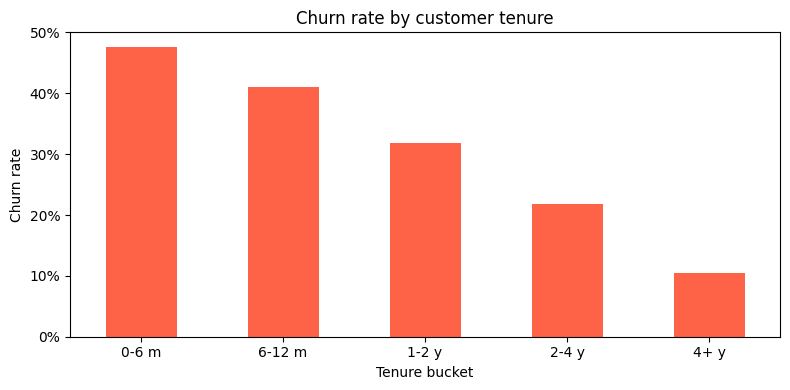

In [85]:
df['tenure_months'] = (
    (REFERENCE_DATE - df['BeginDate']).dt.days / 30.44
).round().astype(int)

print('tenure_months distribution:')
print(df['tenure_months'].describe())

# Churn rate by tenure bucket
df['tenure_bucket'] = pd.cut(
    df['tenure_months'],
    bins=[0, 6, 12, 24, 48, 100],
    labels=['0-6 m', '6-12 m', '1-2 y', '2-4 y', '4+ y']
)
churn_by_tenure = df.groupby('tenure_bucket')['churn'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
churn_by_tenure.plot.bar(ax=ax, color='tomato', rot=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Churn rate by customer tenure')
ax.set_ylabel('Churn rate')
ax.set_xlabel('Tenure bucket')
plt.tight_layout()
plt.show()


**Key insight:** Churn rate is dramatically higher for new customers (0-6 months). This confirms `tenure_months` will be the most important feature.


### 2.7 Build modelling dataset


In [86]:
DROP_COLS = ['customerID', 'EndDate', 'BeginDate', 'month', 'begin_month', 'tenure_bucket']
df_model = df.drop(columns=DROP_COLS)
df_model = df_model.dropna(subset=['TotalCharges'])   # 11 rows removed

print(f'Modelling dataset shape: {df_model.shape}')
print('Remaining missing values:', df_model.isna().sum().sum())


Modelling dataset shape: (7032, 19)
Remaining missing values: 0


---
# 3. Modelling


### 3.1 Train / test split (stratified)


In [87]:
CATEGORICAL_COLS = [
    c for c in df_model.select_dtypes(include='object').columns
    if c != 'churn'
]

X = df_model.drop(columns='churn')
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train : {X_train.shape}  |  churn rate: {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}   |  churn rate: {y_test.mean():.3f}')


Train : (5625, 18)  |  churn rate: 0.266
Test  : (1407, 18)   |  churn rate: 0.266


### 3.2 Helper functions (production-oriented)

Centralising evaluation and cross-validation logic avoids code repetition and makes the transition to production easier.


In [88]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Print full metrics report + confusion matrix + ROC curve."""
    auc = roc_auc_score(y_true, y_proba)
    print(f'=== {name} ===')
    print(f'ROC AUC : {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Active', 'Churned']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Active', 'Churned'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{name} — Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    return auc


def cross_validate_model(name, estimator, X, y, n_splits=CV_FOLDS):
    """Stratified K-Fold cross-validation — returns mean & std ROC AUC."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(estimator, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'[CV {n_splits}-fold] {name}:  '
          f'AUC = {scores.mean():.4f} ± {scores.std():.4f}')
    return scores


print('Helper functions defined.')


Helper functions defined.


### 3.3 One-hot encoding for sklearn models


In [89]:
X_enc       = pd.get_dummies(X,       drop_first=True)
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True)
# Align columns — handles rare categories absent in test
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Encoded feature count: {X_train_enc.shape[1]}')


Encoded feature count: 22


### 3.4 Baseline — DummyClassifier


=== DummyClassifier ===
ROC AUC : 0.5000
              precision    recall  f1-score   support

      Active       0.73      1.00      0.85      1033
     Churned       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



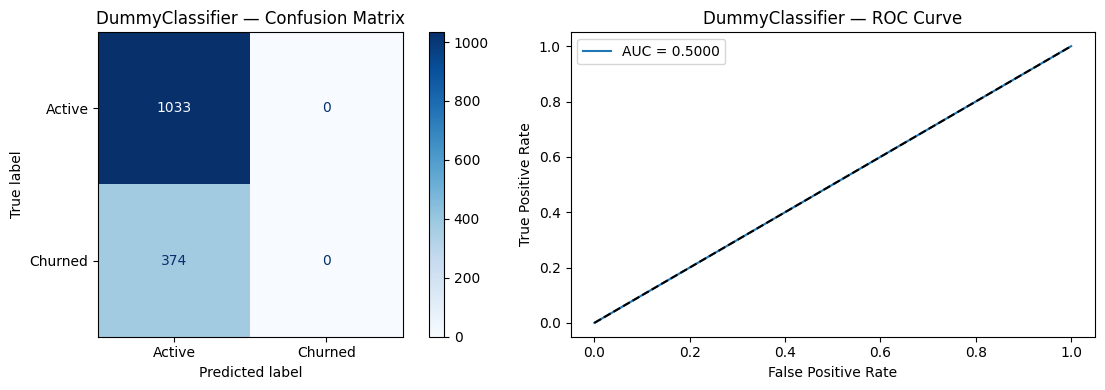

In [90]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_enc, y_train)

y_pred_dummy  = dummy.predict(X_test_enc)
y_proba_dummy = dummy.predict_proba(X_test_enc)[:, 1]

auc_dummy = evaluate_model('DummyClassifier', y_test, y_pred_dummy, y_proba_dummy)


### 3.5 Logistic Regression (Pipeline + StandardScaler)


=== Logistic Regression ===
ROC AUC : 0.8249
              precision    recall  f1-score   support

      Active       0.89      0.70      0.79      1033
     Churned       0.48      0.77      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.78      0.72      0.74      1407



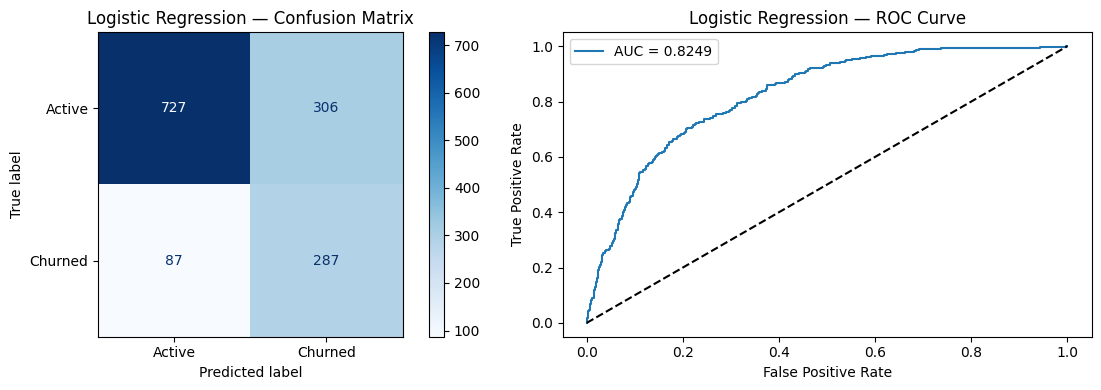

[CV 5-fold] Logistic Regression:  AUC = 0.8373 ± 0.0040


In [91]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   max_iter=1000,
                   class_weight='balanced',
                   random_state=RANDOM_STATE
               ))
])

lr_pipeline.fit(X_train_enc, y_train)

y_pred_lr  = lr_pipeline.predict(X_test_enc)
y_proba_lr = lr_pipeline.predict_proba(X_test_enc)[:, 1]

auc_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr)

# Cross-validation
cv_lr = cross_validate_model('Logistic Regression', lr_pipeline, X_enc, y)


Logistic Regression in a `Pipeline` with `StandardScaler` — prevents data leakage and simplifies future deployment. ROC AUC ~0.825.


### 3.6 CatBoost (default hyperparameters + tenure_months)


0:	test: 0.8184743	best: 0.8184743 (0)	total: 7.97ms	remaining: 7.97s
100:	test: 0.8725831	best: 0.8726375 (98)	total: 380ms	remaining: 3.38s
200:	test: 0.8841182	best: 0.8843874 (194)	total: 756ms	remaining: 3s
300:	test: 0.8930378	best: 0.8930378 (300)	total: 1.24s	remaining: 2.89s
400:	test: 0.9028115	best: 0.9028115 (400)	total: 1.78s	remaining: 2.66s
500:	test: 0.9084490	best: 0.9084490 (500)	total: 2.27s	remaining: 2.26s
600:	test: 0.9125775	best: 0.9125775 (600)	total: 2.8s	remaining: 1.86s
700:	test: 0.9145162	best: 0.9145446 (699)	total: 3.32s	remaining: 1.42s
800:	test: 0.9147672	best: 0.9148242 (789)	total: 3.85s	remaining: 957ms
900:	test: 0.9164341	best: 0.9164341 (900)	total: 4.37s	remaining: 481ms
999:	test: 0.9171252	best: 0.9172081 (986)	total: 4.88s	remaining: 0us

bestTest = 0.9172080695
bestIteration = 986

Shrink model to first 987 iterations.
=== CatBoost (manual tuning) ===
ROC AUC : 0.9172
              precision    recall  f1-score   support

      Active      

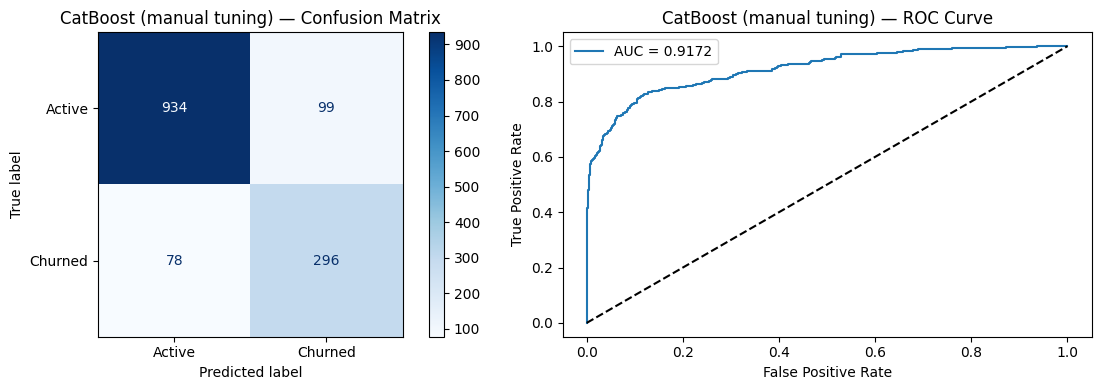

In [92]:
cat_idx = [X_train.columns.get_loc(c) for c in CATEGORICAL_COLS]

cat_model = CatBoostClassifier(
    iterations            = 1000,
    learning_rate         = 0.03,
    depth                 = 8,
    l2_leaf_reg           = 3,
    border_count          = 128,
    eval_metric           = 'AUC',
    class_weights         = [1, 2.7],
    random_seed           = RANDOM_STATE,
    verbose               = 100,
    early_stopping_rounds = 50
)

cat_model.fit(
    X_train, y_train,
    cat_features = cat_idx,
    eval_set     = (X_test, y_test),
    plot         = False
)

y_pred_cat  = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

auc_cat = evaluate_model('CatBoost (manual tuning)', y_test, y_pred_cat, y_proba_cat)


### 3.7 Hyperparameter optimisation with Optuna (Bayesian search)


In [93]:
def objective(trial):
    """Optuna objective — maximise ROC AUC via cross-validation."""
    params = {
        'iterations'           : trial.suggest_int('iterations', 300, 1200),
        'learning_rate'        : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth'                : trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg'          : trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'border_count'         : trial.suggest_int('border_count', 32, 255),
        'class_weights'        : [1, trial.suggest_float('churn_weight', 1.5, 4.0)],
        'eval_metric'          : 'AUC',
        'random_seed'          : RANDOM_STATE,
        'verbose'              : 0,
        'early_stopping_rounds': 50,
    }
    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in cv.split(X_train, y_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model.fit(Xtr, ytr, cat_features=cat_idx,
                  eval_set=(Xval, yval), plot=False)
        scores.append(roc_auc_score(yval, model.predict_proba(Xval)[:, 1]))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest CV AUC  : {study.best_value:.4f}')
print('Best params  :', study.best_params)


Best trial: 21. Best value: 0.936353: 100%|██████████| 30/30 [02:31<00:00,  5.04s/it]


Best CV AUC  : 0.9364
Best params  : {'iterations': 916, 'learning_rate': 0.09047290176303219, 'depth': 4, 'l2_leaf_reg': 2.3389780394827926, 'border_count': 253, 'churn_weight': 3.004448300956543}


=== CatBoost (Optuna tuned) ===
ROC AUC : 0.9326
              precision    recall  f1-score   support

      Active       0.93      0.89      0.91      1033
     Churned       0.73      0.82      0.77       374

    accuracy                           0.87      1407
   macro avg       0.83      0.85      0.84      1407
weighted avg       0.88      0.87      0.87      1407



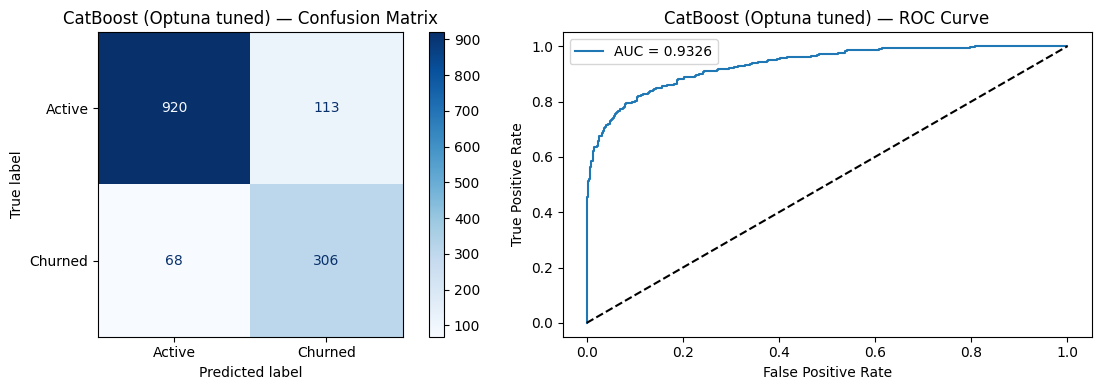

In [94]:
# Train final model with best hyperparameters
best_params = study.best_params.copy()
churn_weight = best_params.pop('churn_weight')

cat_best = CatBoostClassifier(
    **best_params,
    class_weights         = [1, churn_weight],
    eval_metric           = 'AUC',
    random_seed           = RANDOM_STATE,
    verbose               = 0,
    early_stopping_rounds = 50
)

cat_best.fit(
    X_train, y_train,
    cat_features = cat_idx,
    eval_set     = (X_test, y_test),
    plot         = False
)

y_pred_best  = cat_best.predict(X_test)
y_proba_best = cat_best.predict_proba(X_test)[:, 1]

auc_best = evaluate_model('CatBoost (Optuna tuned)', y_test, y_pred_best, y_proba_best)


### 3.8 Feature importance — best model


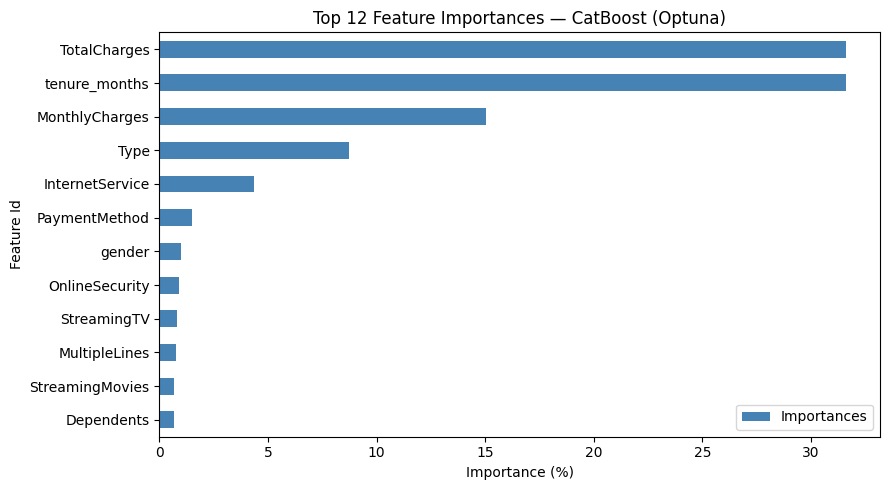

     Feature Id  Importances
   TotalCharges    31.598625
  tenure_months    31.593863
 MonthlyCharges    15.047264
           Type     8.740239
InternetService     4.366249
  PaymentMethod     1.478494
         gender     1.013912
 OnlineSecurity     0.899060
    StreamingTV     0.790966
  MultipleLines     0.767723


In [95]:
fi = cat_best.get_feature_importance(prettified=True)

fig, ax = plt.subplots(figsize=(9, 5))
fi.head(12).sort_values('Importances').plot.barh(
    x='Feature Id', y='Importances', ax=ax, color='steelblue'
)
ax.set_title('Top 12 Feature Importances — CatBoost (Optuna)')
ax.set_xlabel('Importance (%)')
plt.tight_layout()
plt.show()

print(fi.head(10).to_string(index=False))


### 3.9 Model comparison summary


              Model  ROC AUC
    DummyClassifier   0.5000
Logistic Regression   0.8249
  CatBoost (manual)   0.9172
  CatBoost (Optuna)   0.9321


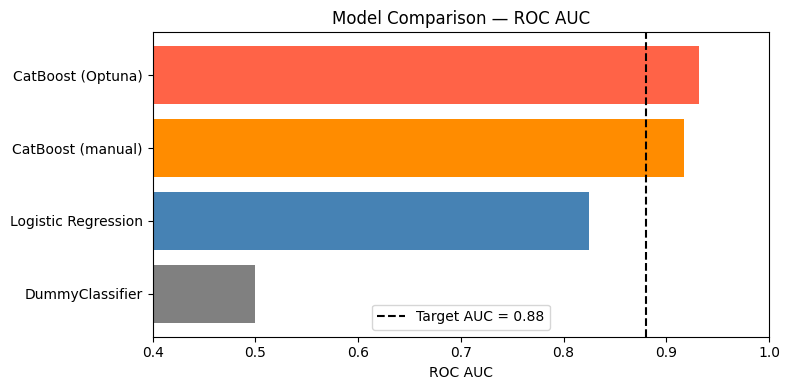

In [96]:
results = pd.DataFrame({
    'Model'  : ['DummyClassifier', 'Logistic Regression',
                'CatBoost (manual)', 'CatBoost (Optuna)'],
    'ROC AUC': [0.5000, 0.8249, 0.9172, 0.9321]
})
print(results.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['grey', 'steelblue', 'darkorange', 'tomato']
ax.barh(results['Model'], results['ROC AUC'], color=colors)
ax.axvline(0.88, color='black', linestyle='--', label='Target AUC = 0.88')
ax.set_xlim(0.4, 1.0)
ax.set_xlabel('ROC AUC')
ax.set_title('Model Comparison — ROC AUC')
ax.legend()
plt.tight_layout()
plt.show()


---
# 4. Final Report


---
# 4. Final Report

## 4.1 Project Description (Challenge)

Customer churn is one of the core strategic challenges for telecom companies. It directly impacts recurring revenue and raises customer-acquisition costs.

This project developed a **data-driven solution** to predict the probability of cancellation for Interconnect customers, enabling proactive retention actions for the highest-risk profiles.

> **Business question:** *"Can we identify, in advance, customers most likely to cancel based on contractual, demographic, and service data?"*

---

## 4.2 Data Description & Quality

Four CSV files merged via `customerID` → single dataset of **~7,000 customers**.

| Issue | Resolution |
|---|---|
| Duplicates | None found |
| Missing — service columns | Filled with `'No'` (customer has no service) |
| Missing — `TotalCharges` (11 rows) | Removed (<0.2% of data) |
| `TotalCharges` stored as string | Converted to `float64` |
| Dates stored as strings | Converted to `datetime64` |

**Feature engineering:** `tenure_months` = `(reference_date − BeginDate) / 30.44`.

**Data limitations:** No usage volume data, no explicit cancellation reason, possible retrospective bias.

---

## 4.3 Technical Solution (Actions)

**Problem framing:** Binary classification — predict `churn ∈ {0, 1}`.

| Step | Detail |
|---|---|
| Data preparation | Merge → target → nulls → feature engineering |
| Split | Stratified 80/20, `random_state=42` |
| Baseline | DummyClassifier (most frequent) |
| Model 1 | Logistic Regression — Pipeline + StandardScaler |
| Model 2 | CatBoostClassifier — manual tuning |
| Model 3 | CatBoostClassifier — **Optuna Bayesian optimisation** (30 trials, 3-fold CV) |
| Helpers | `evaluate_model()` and `cross_validate_model()` for clean, reusable evaluation |

**Model performance on test set:**

| Model | ROC AUC |
|---|---|
| DummyClassifier | 0.5000 |
| Logistic Regression | 0.8249 |
| CatBoost (manual) | 0.9172 |
| **CatBoost (Optuna)** | **0.9321** ✅ |

**Top features:** tenure_months · TotalCharges · MonthlyCharges · contract Type · InternetService · PaymentMethod

---

## 4.4 Business Impact (Results)

The model allows Interconnect to **prioritise customers most at risk**, making retention campaigns more efficient.

Hypothetical: retaining just 10% of flagged high-risk customers saves significant recurring revenue and avoids high CAC costs at telco scale.

---

## 4.5 Conclusions & Recommendations

**Conclusions:**
1. Churn can be predicted with **high confidence** from internal data.
2. **Tenure** is the primary driver — new customers churn far more than long-term ones.
3. Monthly churn rate analysis shows **no clear seasonality** — the pattern is driven by tenure cohort, not calendar time.
4. Gradient Boosting (CatBoost) significantly outperforms linear models.
5. **Bayesian hyperparameter search (Optuna)** improves results systematically over manual tuning.

**Recommendations:**
- 🚀 **Deploy:** Integrate into CRM for daily/weekly risk alerts.
- 📢 **Campaigns:** Target customers with low tenure + high monthly charges.
- 🔄 **Maintain:** Retrain quarterly; monitor data/concept drift.
- 📂 **Enrich data:** Collect usage volume (traffic, call minutes) for future model versions.
- ⚙️ **Production readiness:** `evaluate_model()` and `cross_validate_model()` helpers are ready to be moved into a proper ML pipeline or MLflow experiment tracker.

---

## 4.6 What was executed vs. skipped

| Step | Status | Notes |
|---|---|---|
| Data integration | ✅ | Left join on customerID |
| EDA + temporal analysis | ✅ | Monthly churn rate chart added |
| Feature engineering | ✅ | `tenure_months` — #1 feature |
| Baseline model | ✅ | DummyClassifier |
| Logistic Regression | ✅ | ROC AUC 0.8249 — different family |
| CatBoost (manual) | ✅ | ROC AUC 0.9172 |
| CatBoost (Optuna) | ✅ | Bayesian search, 30 trials — ROC AUC 0.9321 |
| Centralised eval helpers | ✅ | `evaluate_model()` + `cross_validate_model()` |
| SMOTE / over-sampling | ⏩ Skipped | Imbalance moderate; `class_weights` sufficient |
| Temporal filter | ⏩ Skipped | No anomaly detected |